# 06 — Customer Segmentation

## Objective

This notebook identifies behavioral and financial customer segments
using unsupervised learning.

The objective is to discover groups of customers with similar financial
and repayment characteristics and determine whether these groups have
meaningfully different credit-risk profiles.

Customer segmentation is complementary to the Probability of Default
(PD) model:

- The PD model estimates the likelihood of default for an individual
  customer.
- Customer segmentation identifies groups of customers with similar
  characteristics.

The `default` target and model-predicted PD will not be used to create
the clusters. They will only be used after clustering to evaluate the
risk characteristics of each segment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:

FEATURE_PATH = "../data/processed/credit_risk_features.csv"

df = pd.read_csv(FEATURE_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDefault distribution:")
print(df["default"].value_counts())

Dataset shape: (29965, 34)

Columns:
['credit_limit', 'gender', 'education', 'marital_status', 'age', 'repayment_sep', 'repayment_aug', 'repayment_july', 'repayment_jun', 'repayment_may', 'repayment_apr', 'bill_sep', 'bill_aug', 'bill_july', 'bill_jun', 'bill_may', 'bill_apr', 'payment_sep', 'payment_aug', 'payment_july', 'payment_jun', 'payment_may', 'payment_apr', 'default', 'num_delayed_months', 'max_delay', 'avg_delay', 'recent_delay', 'utilization_sep', 'avg_utilization', 'max_utilization', 'total_payment_6m', 'recent_payment_3m', 'older_payment_3m']

Missing values:
0

Default distribution:
default
0    23335
1     6630
Name: count, dtype: int64


## Feature Selection for Clustering

KMeans groups customers based on distance between observations. Therefore,
feature selection is important because highly correlated or differently
scaled variables can disproportionately influence the resulting clusters.

The `default` target is excluded from clustering to prevent target leakage.

We will first examine feature correlations and distributions before
selecting the final variables used by KMeans.

In [3]:
# Exclude the target from clustering candidates
clustering_candidates = df.drop(columns=["default"]).copy()

print("Candidate features:", clustering_candidates.shape[1])
print("\nData types:")
print(clustering_candidates.dtypes.value_counts())

print("\nFeature summary:")
display(clustering_candidates.describe().T)

Candidate features: 33

Data types:
int64      29
float64     4
Name: count, dtype: int64

Feature summary:


,count,mean,std,min,25%,50%,75%,max
credit_limit,29965.0,167442.005006,129760.135222,10000.0,50000.000000,140000.000000,240000.000000,1.000000e+06
gender,29965.0,1.603738,0.489128,1.0,1.000000,2.000000,2.000000,2.000000e+00
education,29965.0,1.853629,0.790411,0.0,1.000000,2.000000,2.000000,6.000000e+00
marital_status,29965.0,1.551877,0.521997,0.0,1.000000,2.000000,2.000000,3.000000e+00
age,29965.0,35.487969,9.219459,21.0,28.000000,34.000000,41.000000,7.900000e+01
repayment_sep,29965.0,-0.016753,1.123492,-2.0,-1.000000,0.000000,0.000000,8.000000e+00
repayment_aug,29965.0,-0.131854,1.196322,-2.0,-1.000000,0.000000,0.000000,8.000000e+00
repayment_july,29965.0,-0.164392,1.195878,-2.0,-1.000000,0.000000,0.000000,8.000000e+00
repayment_jun,29965.0,-0.218922,1.168175,-2.0,-1.000000,0.000000,0.000000,8.000000e+00
repayment_may,29965.0,-0.264509,1.132220,-2.0,-1.000000,0.000000,0.000000,8.000000e+00


## Initial Clustering Feature Set

The clustering model will focus on customer financial capacity,
repayment behavior, credit utilization, and payment activity.

Monthly bill, payment, and repayment variables are initially excluded
because the engineered summary features capture much of their information.
This also prevents the monthly variables from disproportionately
influencing the distance calculation.

Demographic variables are excluded from the initial clustering model
because the objective is to identify financial and behavioral profiles,
rather than demographic groups.

The `default` target is excluded entirely from clustering.

The initial feature set contains:

- credit_limit
- age
- num_delayed_months
- max_delay
- avg_delay
- recent_delay
- avg_utilization
- max_utilization
- total_payment_6m
- recent_payment_3m
- older_payment_3m

In [4]:
segmentation_features = [
    "credit_limit",
    "age",
    "num_delayed_months",
    "max_delay",
    "avg_delay",
    "recent_delay",
    "avg_utilization",
    "max_utilization",
    "total_payment_6m",
    "recent_payment_3m",
    "older_payment_3m"
]

X_seg = df[segmentation_features].copy()

print("Segmentation feature shape:", X_seg.shape)
print("\nSelected features:")
print(segmentation_features)

Segmentation feature shape: (29965, 11)

Selected features:
['credit_limit', 'age', 'num_delayed_months', 'max_delay', 'avg_delay', 'recent_delay', 'avg_utilization', 'max_utilization', 'total_payment_6m', 'recent_payment_3m', 'older_payment_3m']


In [5]:
# Checking skewness
skewness = X_seg.skew().sort_values(ascending=False)

print("Feature skewness:")
display(skewness.to_frame("skewness"))

Feature skewness:


,skewness
recent_payment_3m,23.007671
total_payment_6m,14.613449
older_payment_3m,6.819973
recent_delay,2.811996
num_delayed_months,2.127639
max_delay,1.723266
max_utilization,1.179342
avg_delay,1.170934
credit_limit,0.993491
age,0.732056


In [6]:
print("Features with |skewness| > 1:")
print(skewness[skewness.abs() > 1])

Features with |skewness| > 1:
recent_payment_3m     23.007671
total_payment_6m      14.613449
older_payment_3m       6.819973
recent_delay           2.811996
num_delayed_months     2.127639
max_delay              1.723266
max_utilization        1.179342
avg_delay              1.170934
dtype: float64


## Handling Skewed Features

The payment aggregates show substantial right skew, particularly
`recent_payment_3m`, `total_payment_6m`, and `older_payment_3m`.

Because KMeans uses distance-based clustering, extreme values can
disproportionately influence cluster centers.

A `log1p` transformation will therefore be applied to the three
non-negative payment aggregate features. This transformation reduces
the influence of extreme payment values while preserving the ordering
of customers and handling zero-valued observations safely.

The remaining features will not be log-transformed because their
distributions and meanings are better preserved in their original
scale.

After transformation, all clustering features will be standardized
using `StandardScaler` so that no feature dominates the Euclidean
distance calculation solely because of its measurement scale.

In [7]:
X_seg_transformed = X_seg.copy()

payment_features = [
    "total_payment_6m",
    "recent_payment_3m",
    "older_payment_3m"
]

for feature in payment_features:
    X_seg_transformed[feature] = np.log1p(X_seg_transformed[feature])

print("Skewness after log transformation:")
display(
    X_seg_transformed.skew()
    .sort_values(ascending=False)
    .to_frame("skewness")
)

Skewness after log transformation:


,skewness
recent_delay,2.811996
num_delayed_months,2.127639
max_delay,1.723266
max_utilization,1.179342
avg_delay,1.170934
credit_limit,0.993491
age,0.732056
avg_utilization,0.665062
older_payment_3m,-1.798582
recent_payment_3m,-2.301422


In [8]:
scaler = StandardScaler()

X_seg_scaled = scaler.fit_transform(X_seg_transformed)

print("Original shape:", X_seg.shape)
print("Transformed shape:", X_seg_transformed.shape)
print("Scaled shape:", X_seg_scaled.shape)

print("\nScaled feature means:")
print(np.round(X_seg_scaled.mean(axis=0), 4))

print("\nScaled feature standard deviations:")
print(np.round(X_seg_scaled.std(axis=0), 4))

Original shape: (29965, 11)
Transformed shape: (29965, 11)
Scaled shape: (29965, 11)

Scaled feature means:
[-0.  0. -0. -0. -0.  0.  0. -0. -0. -0.  0.]

Scaled feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Selecting the Number of Clusters

The number of customer segments is not predetermined from the existing
Low, Medium, and High risk tiers.

Risk tiers are supervised decision categories based on model-estimated
Probability of Default, whereas customer segments are unsupervised
groups based on financial and behavioral similarity.

To determine an appropriate number of clusters, KMeans will be evaluated
for K values from 2 through 8.

Two complementary measures will be used:

- Inertia (elbow method): measures within-cluster variation. Lower values
  indicate more compact clusters, although inertia will naturally decrease
  as K increases.
- Silhouette score: measures how well each observation fits its assigned
  cluster relative to other clusters. Higher values generally indicate
  better-separated and more cohesive clusters.

The final K will be selected by considering both metrics together rather
than optimizing a single metric mechanically.

In [9]:
k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_seg_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_seg_scaled, labels)
    )

results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

display(results)

,k,inertia,silhouette_score
0,2,243489.113304,0.320719
1,3,194167.632014,0.350777
2,4,161538.132704,0.265769
3,5,146265.703524,0.268005
4,6,133692.815020,0.239510
5,7,124236.630673,0.239689
6,8,115629.754915,0.247709


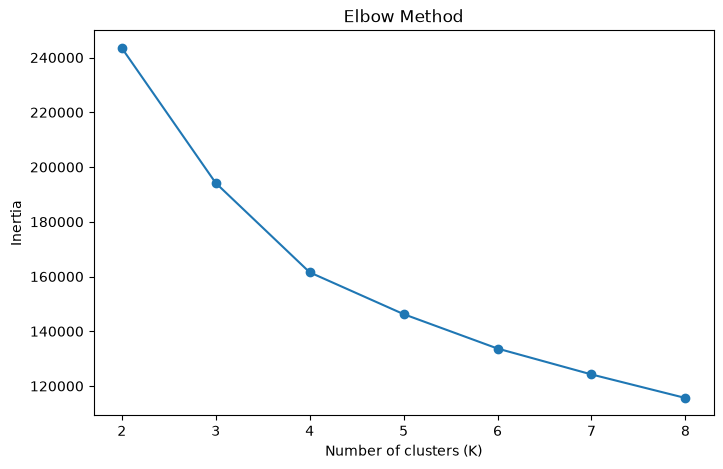

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(results["k"], results["inertia"], marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(results["k"])
plt.show()

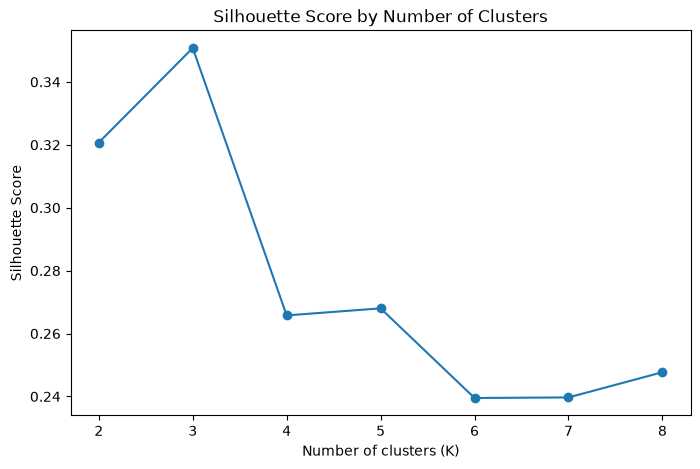

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(
    results["k"],
    results["silhouette_score"],
    marker="o"
)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(results["k"])
plt.show()

## Cluster Count Selection

The evaluation supports selecting K = 3 for the final customer
segmentation.

The silhouette score reaches its highest value at K = 3 (0.3508),
indicating the strongest separation and internal cohesion among the
tested cluster counts.

The elbow analysis also shows a substantial reduction in inertia up to
K = 3, followed by diminishing improvements as additional clusters are
introduced.

Although the silhouette score is moderate rather than exceptionally
high, K = 3 provides the best overall balance between cluster quality,
separation, and interpretability.

Therefore, three customer segments will be used for the final
segmentation model.

Importantly, these three segments are not equivalent to the Low,
Medium, and High PD risk tiers. The clusters are discovered from
customer financial and behavioral characteristics, while the risk tiers
are defined from model-estimated Probability of Default.

In [12]:
FINAL_K = 3

kmeans_final = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_seg_scaled)

df["customer_segment"] = cluster_labels

print("Cluster counts:")
print(df["customer_segment"].value_counts().sort_index())

Cluster counts:
customer_segment
0     2164
1    19704
2     8097
Name: count, dtype: int64


In [13]:
cluster_distribution = (
    df["customer_segment"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Cluster distribution (%):")
print(cluster_distribution)

Cluster distribution (%):
customer_segment
0     7.22
1    65.76
2    27.02
Name: proportion, dtype: float64


## Customer Segment Profiles

KMeans cluster labels are arbitrary numerical identifiers and do not
have an inherent business interpretation.

To understand the segments, we will compare their financial and
behavioral characteristics using the original, untransformed feature
values.

The cluster profiles will be examined using:

- average credit limit
- age
- repayment delay behavior
- credit utilization
- payment activity
- payment trends

This allows the numerical clusters to be translated into meaningful
customer profiles.

In [14]:
profile_features = [
    "credit_limit",
    "age",
    "num_delayed_months",
    "max_delay",
    "avg_delay",
    "recent_delay",
    "avg_utilization",
    "max_utilization",
    "total_payment_6m",
    "recent_payment_3m",
    "older_payment_3m"
]

cluster_profiles = (
    df.groupby("customer_segment")[profile_features]
    .mean()
    .round(2)
)

display(cluster_profiles)

,credit_limit,age,num_delayed_months,max_delay,avg_delay,recent_delay,avg_utilization,max_utilization,total_payment_6m,recent_payment_3m,older_payment_3m
customer_segment,,,,,,,,,,,
0,186210.72,36.40,0.96,0.87,0.78,0.63,0.01,0.06,681.46,173.74,507.72
1,189459.89,35.64,0.04,0.04,0.04,0.04,0.34,0.48,39790.64,21211.71,18578.93
2,108845.50,34.88,2.73,2.19,1.98,1.06,0.54,0.66,20256.26,10617.84,9638.42


In [15]:
cluster_medians = (
    df.groupby("customer_segment")[profile_features]
    .median()
    .round(2)
)

display(cluster_medians)

,credit_limit,age,num_delayed_months,max_delay,avg_delay,recent_delay,avg_utilization,max_utilization,total_payment_6m,recent_payment_3m,older_payment_3m
customer_segment,,,,,,,,,,,
0,180000.0,35.0,1.0,1.0,1.0,0.0,0.00,0.00,0.0,0.0,0.0
1,170000.0,34.0,0.0,0.0,0.0,0.0,0.23,0.38,19712.0,9500.0,7637.5
2,80000.0,33.0,2.0,2.0,2.0,1.0,0.59,0.74,10821.0,5600.0,4570.0


## Segment Risk Validation

The initial cluster profiles show meaningful differences in customer
financial and repayment behavior.

However, behavioral characteristics alone should not be used to assign
risk labels to the clusters.

The existing default outcome and model-estimated Probability of Default
(PD) will therefore be used only after clustering to evaluate the risk
profile of each segment.

This allows us to determine whether the discovered customer segments
have materially different observed default rates and model-estimated
risk.

The customer segments remain unsupervised groups; they are not
redefined as risk tiers.

In [16]:
segment_risk = (
    df.groupby("customer_segment")
    .agg(
        customers=("default", "size"),
        observed_default_rate=("default", "mean")
    )
)

segment_risk["observed_default_rate"] *= 100

display(segment_risk.round(2))

,customers,observed_default_rate
customer_segment,,
0,2164,34.01
1,19704,11.30
2,8097,45.30


In [17]:
print(df.columns.tolist())

['credit_limit', 'gender', 'education', 'marital_status', 'age', 'repayment_sep', 'repayment_aug', 'repayment_july', 'repayment_jun', 'repayment_may', 'repayment_apr', 'bill_sep', 'bill_aug', 'bill_july', 'bill_jun', 'bill_may', 'bill_apr', 'payment_sep', 'payment_aug', 'payment_july', 'payment_jun', 'payment_may', 'payment_apr', 'default', 'num_delayed_months', 'max_delay', 'avg_delay', 'recent_delay', 'utilization_sep', 'avg_utilization', 'max_utilization', 'total_payment_6m', 'recent_payment_3m', 'older_payment_3m', 'customer_segment']


## Segment Default Risk Comparison

The observed default rates differ substantially across the three
unsupervised customer segments.

Segment 1 has the lowest observed default rate (11.30%), while Segment 0
has a substantially higher rate (34.01%) and Segment 2 has the highest
rate (45.30%).

This provides evidence that the behavioral clusters capture meaningful
differences in credit outcomes, despite the default target not being
used during KMeans clustering.

The results also show why cluster labels cannot be assigned a risk
meaning based solely on their numerical identifiers. Segment 0, for
example, initially appeared to represent a low-activity customer group,
but its observed default rate indicates materially elevated risk.

The next analysis compares these behavioral segments with the
supervised model's Probability of Default (PD) and project-defined
risk tiers.

In [18]:
import os

for root, dirs, files in os.walk("../data"):
    for file in files:
        print(os.path.join(root, file))

../data/processed/credit_risk_clean.csv
../data/processed/customer_risk_output.csv
../data/processed/credit_risk_features.csv
../data/raw/default_of_credit_card_clients.csv


## Integrating Model-Based PD Risk

The customer segmentation is unsupervised, while Probability of Default
(PD) is produced by the supervised XGBoost credit-risk model.

To compare the two perspectives, the existing customer-level PD output
from the credit-risk modeling stage is integrated with the KMeans
segments.

The model is not retrained and new predictions are not generated.
Instead, the previously validated PD estimates are reused to ensure
consistency between the credit-risk and customer-segmentation analyses.

In [19]:
pd_output = pd.read_csv("../data/processed/customer_risk_output.csv")

print("PD output shape:", pd_output.shape)
print("PD output columns:")
print(pd_output.columns.tolist())

display(pd_output.head())

PD output shape: (5993, 4)
PD output columns:
['customer_index', 'pd', 'risk_tier', 'actual_default']


,customer_index,pd,risk_tier,actual_default
0,8681,0.102868,Medium,0
1,24179,0.077565,Low,0
2,27755,0.155555,Medium,0
3,14938,0.165420,Medium,0
4,1486,0.011902,Low,0


## Aligning Customer Segments with PD Risk

The KMeans segmentation was generated for the complete customer
population, whereas the validated PD output contains the held-out test
customers only.

To ensure a valid comparison, the PD records are aligned with the
corresponding customers using `customer_index`.

This prevents accidental comparison of different customer populations
and preserves the separation between model development and final
evaluation.

The resulting dataset contains the test customers with both:

- unsupervised customer segment
- supervised Probability of Default (PD)
- project-defined PD risk tier
- observed default outcome

In [20]:
print("Segmentation rows:", len(df))
print("PD rows:", len(pd_output))

print(
    "Unique customer indexes in PD output:",
    pd_output["customer_index"].nunique()
)

print(
    "Customer index range:",
    pd_output["customer_index"].min(),
    "to",
    pd_output["customer_index"].max()
)

Segmentation rows: 29965
PD rows: 5993
Unique customer indexes in PD output: 5993
Customer index range: 1 to 29964


In [21]:
print("df index name:", df.index.name)
print("df index range:", df.index.min(), "to", df.index.max())

df index name: None
df index range: 0 to 29964


## Test-Set Segment and PD Integration

The customer-level PD output contains the same original customer indices
used by the segmentation dataset.

The two datasets are therefore aligned using `customer_index` and the
original dataframe index.

Only the 5,993 held-out test customers are retained for this analysis.
This ensures that the comparison between customer segments, PD risk
tiers, and observed defaults is performed on the same population used
for final model evaluation.

No model predictions are regenerated during this step.

In [22]:
# Copy the segmentation dataframe
test_segment_data = df.copy()

# Preserve the original customer index
test_segment_data["customer_index"] = test_segment_data.index

# Keep only customers present in the validated PD output
test_segment_data = test_segment_data[
    test_segment_data["customer_index"].isin(pd_output["customer_index"])
].copy()

# Merge existing PD and risk-tier results
test_segment_data = test_segment_data.merge(
    pd_output[["customer_index", "pd", "risk_tier", "actual_default"]],
    on="customer_index",
    how="inner"
)

print("Integrated dataset shape:", test_segment_data.shape)
print("Unique customers:", test_segment_data["customer_index"].nunique())

Integrated dataset shape: (5993, 39)
Unique customers: 5993


In [23]:
print(
    test_segment_data[
        ["customer_index", "customer_segment", "pd", "risk_tier", "default", "actual_default"]
    ].head(10)
)

   customer_index  customer_segment        pd risk_tier  default  \
0               1                 2  0.302622      High        1   
1              11                 2  0.106753    Medium        0   
2              14                 1  0.042980       Low        0   
3              17                 1  0.067433       Low        0   
4              20                 1  0.086979       Low        0   
5              21                 1  0.258358    Medium        1   
6              26                 1  0.209689    Medium        1   
7              33                 1  0.020859       Low        0   
8              34                 1  0.043488       Low        0   
9              45                 0  0.242550    Medium        1   

   actual_default  
0               1  
1               0  
2               0  
3               0  
4               0  
5               1  
6               1  
7               0  
8               0  
9               1  


In [24]:
print(
    "Default agreement:",
    (
        test_segment_data["default"]
        == test_segment_data["actual_default"]
    ).mean()
)

Default agreement: 1.0


In [25]:
# Segment distribution in the test test
segment_test_distribution = (
    test_segment_data["customer_segment"]
    .value_counts()
    .sort_index()
)

segment_test_percentage = (
    test_segment_data["customer_segment"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

display(
    pd.DataFrame({
        "customers": segment_test_distribution,
        "percentage": segment_test_percentage.round(2)
    })
)

,customers,percentage
customer_segment,,
0,426,7.11
1,3950,65.91
2,1617,26.98


## Customer Segments and Model-Based Risk Tiers

The integrated test dataset now contains both unsupervised customer
segments and supervised PD risk tiers.

This analysis compares the two approaches to determine whether the
behavioral customer segments correspond to different levels of
model-estimated credit risk.

Customer segmentation and PD risk tiers serve different purposes:

- Customer segments describe groups of customers with similar financial
  and behavioral characteristics.
- PD risk tiers describe the estimated probability of default for an
  individual customer.

Comparing the two helps determine whether behavioral segmentation adds
useful information beyond the supervised credit-risk model.

In [26]:
segment_risk_table = pd.crosstab(
    test_segment_data["customer_segment"],
    test_segment_data["risk_tier"],
    normalize="index"
) * 100

segment_risk_table = segment_risk_table.round(2)

display(segment_risk_table)

risk_tier,High,Low,Medium
customer_segment,,,
0,46.95,3.05,50.00
1,1.44,53.16,45.39
2,67.41,2.23,30.36


In [28]:
# Average PD by segment
segment_pd_summary = (
    test_segment_data
    .groupby("customer_segment")
    .agg(
        customers=("customer_index", "count"),
        average_pd=("pd", "mean"),
        median_pd=("pd", "median"),
        observed_default_rate=("actual_default", "mean")
    )
)

segment_pd_summary["observed_default_rate"] *= 100
segment_pd_summary["average_pd"] *= 100
segment_pd_summary["median_pd"] *= 100

segment_pd_summary = segment_pd_summary.round(2)

display(segment_pd_summary)

,customers,average_pd,median_pd,observed_default_rate
customer_segment,,,,
0,426,34.98,28.90,33.80
1,3950,10.84,9.47,11.90
2,1617,45.16,42.61,44.03


## Segment-Level Default Risk Validation

The final validation compares observed default rates across the three
customer segments using the held-out test population.

A meaningful segmentation should produce groups with materially different
default rates rather than clusters that differ only in descriptive
characteristics.

The results are also compared with the model-estimated PD to determine
whether the behavioral segments align with observed credit risk.

In [29]:
segment_default_summary = (
    test_segment_data
    .groupby("customer_segment")
    .agg(
        customers=("customer_index", "count"),
        observed_default_rate=("actual_default", "mean"),
        average_pd=("pd", "mean")
    )
)

segment_default_summary["observed_default_rate"] *= 100
segment_default_summary["average_pd"] *= 100

segment_default_summary = segment_default_summary.round(2)

display(segment_default_summary)

,customers,observed_default_rate,average_pd
customer_segment,,,
0,426,33.80,34.98
1,3950,11.90,10.84
2,1617,44.03,45.16


In [30]:
segment_default_rates = segment_default_summary["observed_default_rate"]

print(
    "Default-rate spread:",
    round(
        segment_default_rates.max() - segment_default_rates.min(),
        2
    ),
    "percentage points"
)

Default-rate spread: 32.13 percentage points


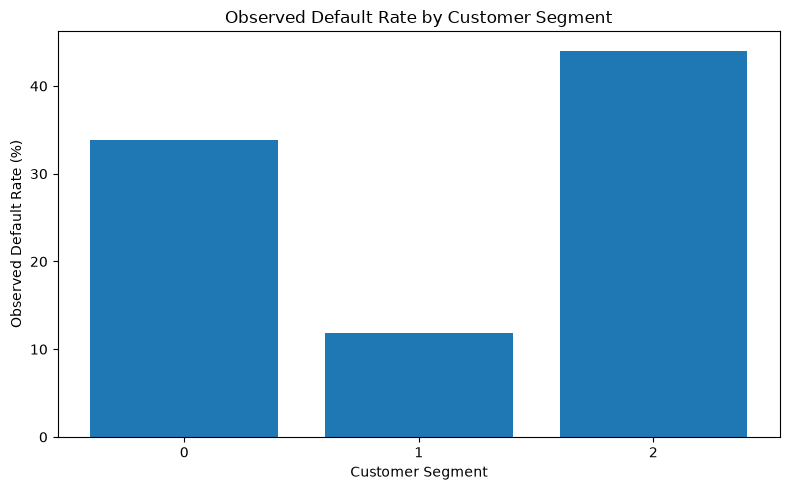

In [31]:
# Bar chart of observed default rate by customer segment.
plt.figure(figsize=(8, 5))

plt.bar(
    segment_default_summary.index.astype(str),
    segment_default_summary["observed_default_rate"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Observed Default Rate (%)")
plt.title("Observed Default Rate by Customer Segment")
plt.tight_layout()
plt.show()

# Customer Segmentation Summary

KMeans clustering was applied to standardized behavioral and financial
features to identify groups of customers with similar credit profiles.

The number of clusters was evaluated using both the elbow method and
silhouette score. K=3 was selected because it achieved the highest
silhouette score (approximately 0.351) while also providing a meaningful
elbow in the inertia curve.

The three resulting customer segments have distinct behavioral profiles:

- **Segment 1 — Lower-risk behavioral segment:**  
  Customers generally show few or no delayed payments, low average and
  maximum delays, and relatively stronger payment behavior. This segment
  represents approximately 66% of the test population and has an observed
  default rate of 11.90%.

- **Segment 0 — Elevated-risk behavioral segment:**  
  Customers show moderate payment-delay behavior combined with relatively
  low payment activity. This segment represents approximately 7% of the
  test population and has an observed default rate of 33.80%.

- **Segment 2 — Highest-risk behavioral segment:**  
  Customers exhibit substantially more delayed payments, higher average
  and maximum delays, and higher utilization. This segment represents
  approximately 27% of the test population and has an observed default
  rate of 44.03%.

The segmentation was then aligned with the XGBoost Probability of Default
(PD) output using the original customer index. This comparison showed
strong agreement between behavioral segments and model-estimated risk.

Average PD increased from 10.84% in Segment 1 to 34.98% in Segment 0 and
45.16% in Segment 2. These estimates were also close to the corresponding
observed default rates of 11.90%, 33.80%, and 44.03%.

The difference between the lowest- and highest-risk segments was 32.13
percentage points in observed default rate.

These results indicate that the unsupervised segmentation identifies
meaningfully different customer populations that are also associated with
substantially different levels of credit risk.

The KMeans segments and XGBoost PD risk tiers serve different purposes:
KMeans provides behavioral customer profiles, while PD risk tiers provide
individual model-based default risk. Their combination can therefore
support downstream customer profiling, risk analysis, and dashboard
visualization.